In [2]:
import numpy as np

import pandas as pd

df2 = pd.read_csv(r'.\files\df1.csv')

# Exploratory Data Analysis (EDA)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [ ]:
# df2 = df1.copy()

## Price & Size Analysis

### 1) What is the distribution of property prices?

In [ ]:
df2['Price'].skew()     # symmetric

np.float64(0.008205887533931273)

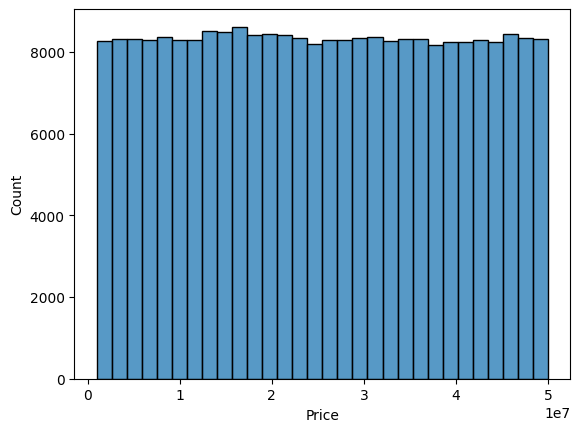

In [ ]:
sns.histplot(df2['Price'], bins = 30)

plt.show()

In [ ]:
# fig = px.histogram(df2['Price'], nbins=30)

# fig.show()

In [ ]:
df2.groupby(['Property_Type'])['Price'].mean()

Property_Type
Apartment            2.546221e+07
Independent House    2.553741e+07
Villa                2.537688e+07
Name: Price, dtype: float64

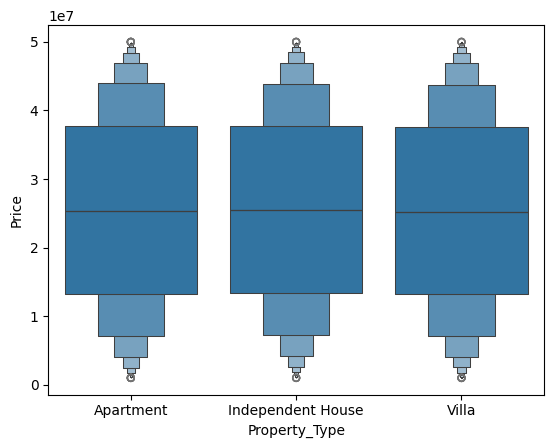

In [ ]:
sns.boxenplot(data=df2, x = 'Property_Type', y = 'Price')

plt.show()

In [ ]:
# fig = px.box(x = df2['Property_Type'], y = df2['Price'])

# fig.show()

### 2) What is the distribution of property sizes?

In [ ]:
df2['Size_in_SqFt'].skew()      # symmetric

np.float64(0.0007959572519020365)

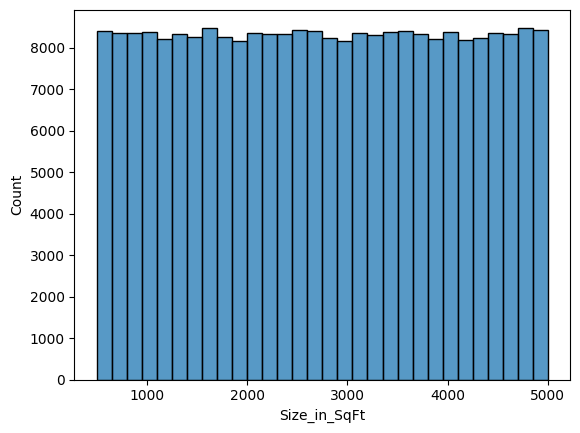

In [ ]:
sns.histplot(df2['Size_in_SqFt'], bins = 30)

plt.show()

In [ ]:
# fig = px.histogram(df2['Size_in_SqFt'], nbins=30)

# fig.show()

In [ ]:
df2.groupby(['Property_Type'])['Size_in_SqFt'].mean()

Property_Type
Apartment            2751.174333
Independent House    2742.612017
Villa                2755.627926
Name: Size_in_SqFt, dtype: float64

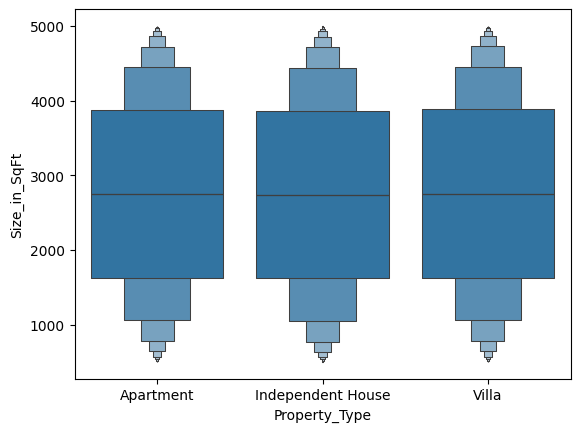

In [ ]:
sns.boxenplot(data=df2, x = 'Property_Type', y = 'Size_in_SqFt')

plt.show()

### 3) How does the price per sq ft vary by property type?

In [ ]:
df2.groupby(['Property_Type'])['Price_per_SqFt'].mean()

Property_Type
Apartment            13046.822376
Independent House    13101.549016
Villa                13025.107864
Name: Price_per_SqFt, dtype: float64

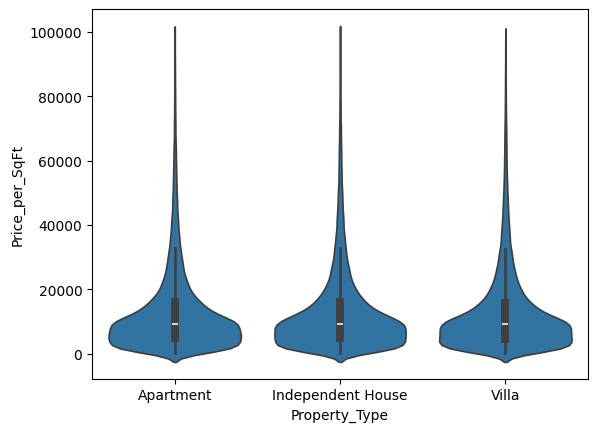

In [ ]:
sns.violinplot(data=df2, x='Property_Type', y='Price_per_SqFt')

plt.show()

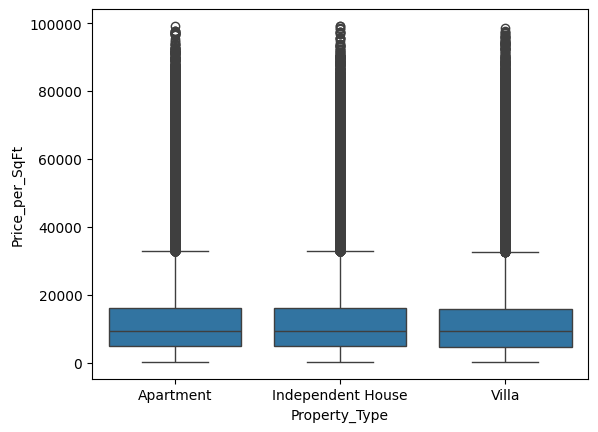

In [ ]:
sns.boxplot(data = df2, x='Property_Type', y='Price_per_SqFt')

plt.show()

In [ ]:
# fig = px.box(x = df2['Property_Type'], y = df2['Price_per_SqFt'])

# fig.show()

### 4) Is there a relationship between property size and price?

In [ ]:
df2['Price'].corr(df2['Size_in_SqFt'])             # no correlation

np.float64(-0.002528546790483089)

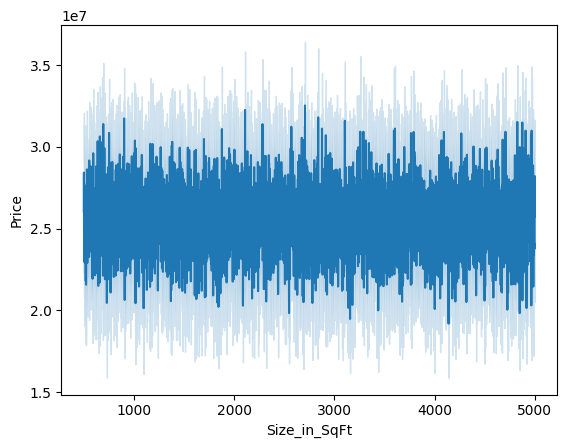

In [ ]:
sns.lineplot(data = df2, x = 'Size_in_SqFt', y = 'Price')

plt.show()

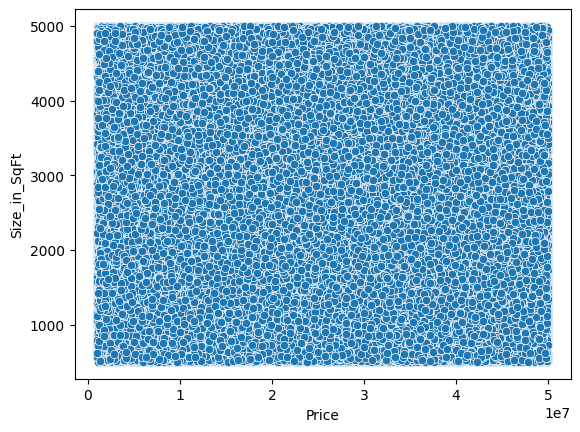

In [ ]:
sns.scatterplot(data = df2, x = 'Price', y = 'Size_in_SqFt')

plt.show()

In [ ]:
# fig = px.scatter(x = df2['Price'], y = df2['Size_in_SqFt'])

# fig.show()

### 5) Are there any outliers in price per sq ft or property size?

#### Price_per_SqFt

##### boxplot

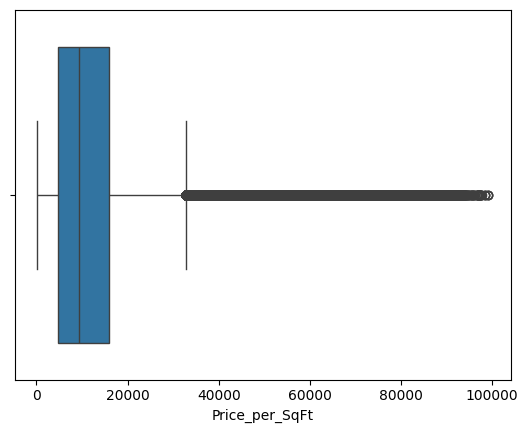

In [ ]:
sns.boxplot(data = df2, x = 'Price_per_SqFt')

plt.show()

In [ ]:
# fig = px.box(df2['Price_per_SqFt'])

# fig.show()

##### Z-Score

In [ ]:
from scipy import stats

z_score_price_per_sqft = stats.zscore(df2['Price_per_SqFt'])

z_score_price_per_sqft = np.abs(z_score_price_per_sqft)

len(z_score_price_per_sqft[z_score_price_per_sqft > 3])

6231

##### IQR (Interquartile Range)

In [ ]:
Q1 = df2['Price_per_SqFt'].quantile(0.25)

Q3 = df2['Price_per_SqFt'].quantile(0.75)

IQR = Q3 - Q1

lower_range = Q1 - (1.5 * IQR)

upper_range = Q3 + (1.5 * IQR)

In [ ]:
len(df2[df2['Price_per_SqFt'] < lower_range]['Price_per_SqFt'])

0

In [ ]:
len(df2[df2['Price_per_SqFt'] > upper_range]['Price_per_SqFt'])

19723

#### Property_Size

##### boxplot

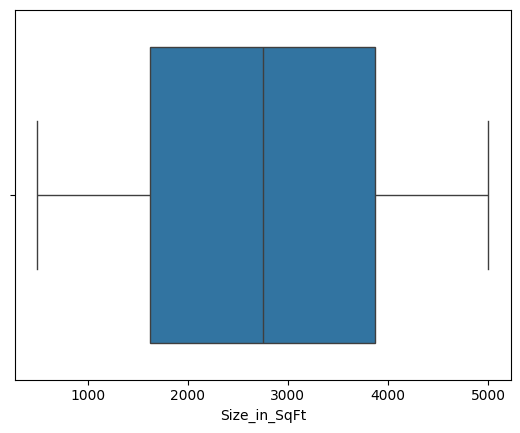

In [ ]:
sns.boxplot(data = df2, x = 'Size_in_SqFt')

plt.show()

In [ ]:
# fig = px.box(df2['Size_in_SqFt'])

# fig.show()

##### Z-score

In [ ]:
from scipy import stats

z_score_size_in_sqft = stats.zscore(df2['Size_in_SqFt'])

z_score_size_in_sqft = np.abs(z_score_size_in_sqft)

len(z_score_size_in_sqft[z_score_size_in_sqft > 3])

0

##### IQR (Interquartile Range)

In [ ]:
Q1 = df2['Size_in_SqFt'].quantile(0.25)

Q3 = df2['Size_in_SqFt'].quantile(0.75)

IQR = Q3 - Q1

lower_range = Q1 - (1.5 * IQR)

upper_range = Q3 + (1.5 * IQR)

In [ ]:
len(df2[df2['Price_per_SqFt'] < lower_range]['Price_per_SqFt'])

0

In [ ]:
len(df2[df2['Price_per_SqFt'] > upper_range]['Price_per_SqFt'])

152950

## Location-based Analysis

### 6) What is the average price per sq ft by state?

In [3]:
df2.groupby(['State'])['Price_per_SqFt'].mean()

State
Andhra Pradesh    13201.081769
Assam             13083.522167
Bihar             13050.121918
Chhattisgarh      13026.631744
Delhi             12940.852215
Gujarat           13090.641755
Haryana           13068.245412
Jharkhand         12974.967067
Karnataka         13251.703799
Kerala            12981.719148
Madhya Pradesh    13068.534576
Maharashtra       13069.638315
Odisha            13032.423074
Punjab            12930.986737
Rajasthan         12931.675375
Tamil Nadu        13131.924143
Telangana         13092.599011
Uttar Pradesh     13142.019348
Uttarakhand       13026.594032
West Bengal       13060.050230
Name: Price_per_SqFt, dtype: float64

In [4]:
q2_1 = df2.groupby(['State'])['Price_per_SqFt'].mean()

type(q2_1)

pandas.core.series.Series

[]

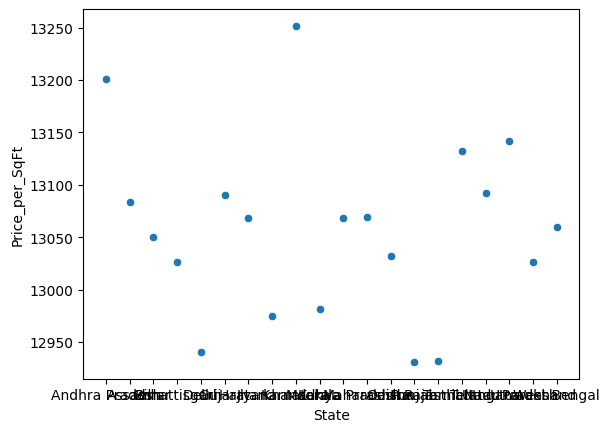

In [15]:
sns.scatterplot(q2_1)

plt.plot()

### 7) What is the average property price by city?

In [ ]:
df2.groupby(['City'])['Price'].mean()

City
Ahmedabad         2.535868e+07
Amritsar          2.524298e+07
Bangalore         2.584566e+07
Bhopal            2.564989e+07
Bhubaneswar       2.549022e+07
Bilaspur          2.518793e+07
Chennai           2.568302e+07
Coimbatore        2.565047e+07
Cuttack           2.507867e+07
Dehradun          2.568901e+07
Durgapur          2.541002e+07
Dwarka            2.534543e+07
Faridabad         2.548624e+07
Gaya              2.570534e+07
Gurgaon           2.540275e+07
Guwahati          2.529927e+07
Haridwar          2.524760e+07
Hyderabad         2.565941e+07
Indore            2.554138e+07
Jaipur            2.552462e+07
Jamshedpur        2.526262e+07
Jodhpur           2.539479e+07
Kochi             2.574152e+07
Kolkata           2.539149e+07
Lucknow           2.562124e+07
Ludhiana          2.531596e+07
Mangalore         2.569209e+07
Mumbai            2.520566e+07
Mysore            2.568482e+07
Nagpur            2.555320e+07
New Delhi         2.516143e+07
Noida             2.562872e+07
Pat

### 8) What is the median age of properties by locality?

In [ ]:
df2.groupby('Locality')['Age_of_Property'].median()

Locality
Locality_1      20.0
Locality_10     17.0
Locality_100    19.0
Locality_101    19.0
Locality_102    19.0
                ... 
Locality_95     19.0
Locality_96     19.0
Locality_97     18.0
Locality_98     18.0
Locality_99     20.0
Name: Age_of_Property, Length: 500, dtype: float64

### 9) How is BHK distributed across cities?

In [ ]:
len(df2['City'].unique())

42

In [ ]:
df2.groupby(['City', "BHK"])['BHK'].sum()

City       BHK
Ahmedabad  1      1264
           2      2534
           3      3816
           4      5032
           5      6750
                  ... 
Warangal   1      1255
           2      2556
           3      3606
           4      4984
           5      6425
Name: BHK, Length: 210, dtype: int64

### 10) What are the price trends for the top 5 most expensive localities?


In [ ]:
top_locality = df2.groupby(['Locality'])['Price'].mean().sort_values(ascending=False).head(5)

In [ ]:
top_5_name = top_locality.index.tolist()

df_top_5 = df2[df2['Locality'].isin(top_5_name)][['Locality', 'Price', 'Year_Built']]

In [ ]:
df_top_5

,Locality,Price,Year_Built
ID,,,
217,Locality_360,40184000,2009
420,Locality_497,9711000,2011
473,Locality_360,6851000,2011
633,Locality_203,13375000,2001
657,Locality_203,23044000,2016
...,...,...,...
249498,Locality_360,45180000,2005
249525,Locality_497,49014000,2015
249642,Locality_360,40736000,2023


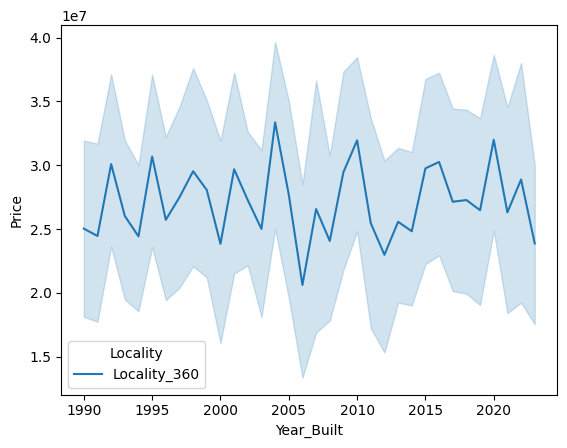

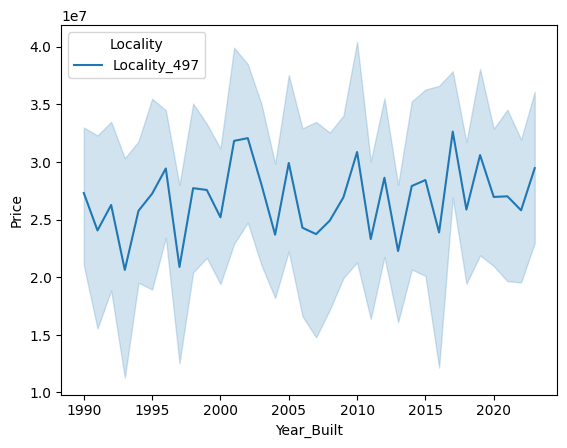

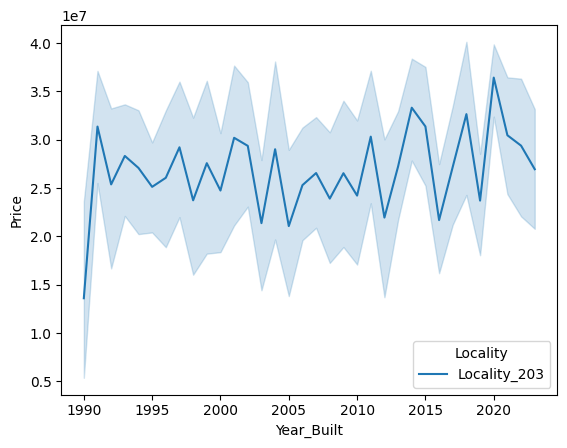

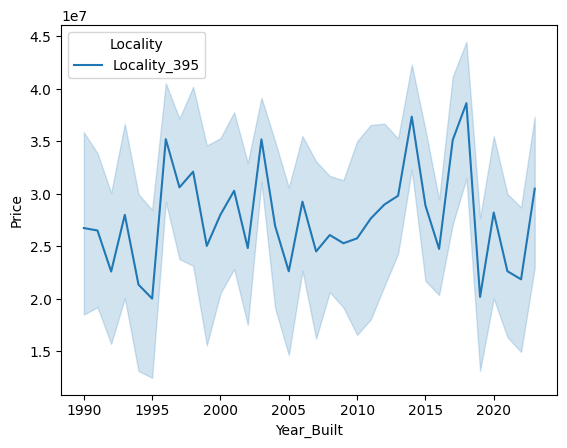

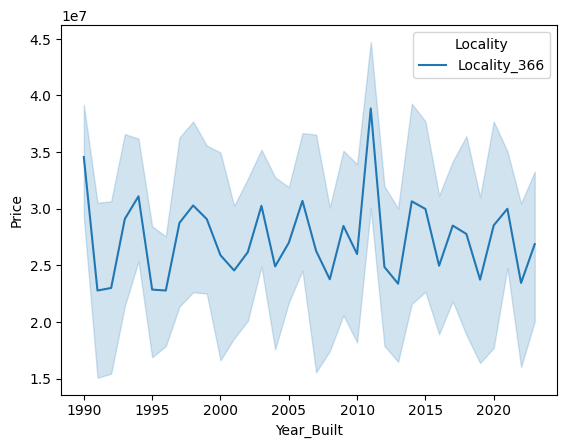

In [ ]:
for i in df_top_5['Locality'].unique():
    
    sns.lineplot(data = df_top_5, x = 'Year_Built', y = 'Price', hue=df_top_5[df_top_5['Locality'] == i]['Locality'])

    plt.show()


## Feature Relationship & Correlation

### 11) How are numeric features correlated with each other?

In [ ]:
df2.corr(numeric_only=True)

,BHK,Size_in_SqFt,Price,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
BHK,1.000000,-0.001033,-0.000980,0.001138,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162
Size_in_SqFt,-0.001033,1.000000,-0.002529,-0.614610,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695
Price,-0.000980,-0.002529,1.000000,0.555781,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769
Price_per_SqFt,0.001138,-0.614610,0.555781,1.000000,-0.001330,-0.001904,0.004161,0.001330,-0.000058,-0.000122
Year_Built,0.000917,0.004135,0.002714,-0.001330,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719
Floor_No,0.001263,-0.002775,-0.001719,-0.001904,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428
Total_Floors,-0.002862,-0.003451,0.001283,0.004161,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867
Age_of_Property,-0.000917,-0.004135,-0.002714,0.001330,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719
Nearby_Schools,-0.000762,0.001966,0.000155,-0.000058,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246
Nearby_Hospitals,0.001162,-0.001695,-0.002769,-0.000122,-0.002719,0.001428,-0.005867,0.002719,-0.002246,1.000000


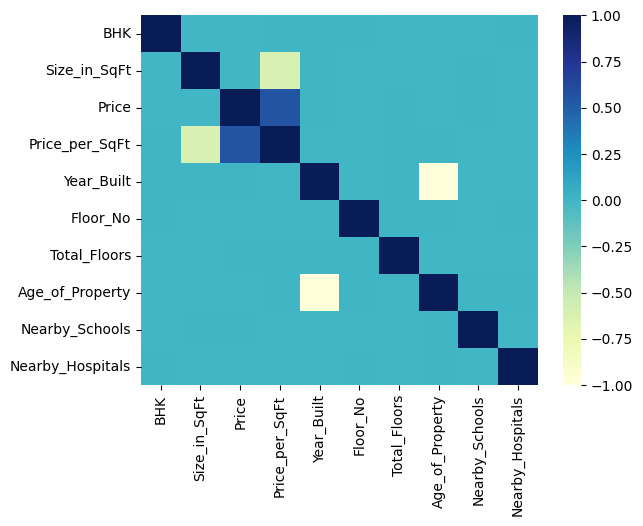

In [ ]:
sns.heatmap(df2.corr(numeric_only=True), cmap="YlGnBu")

plt.show()

### 12) How do nearby schools relate to price per sq ft?

In [16]:
df2['Nearby_Schools'].corr(df2['Price_per_SqFt'])

np.float64(-5.819365957235474e-05)

In [18]:
# sns.lineplot(x = df2['Price_per_SqFt'], y = df2['Nearby_Schools'])

# plt.show()

### 13) How do nearby hospitals relate to price per sq ft?

In [ ]:
df2['Nearby_Hospitals'].corr(df2['Price_per_SqFt'])

np.float64(-0.00012213707055864755)

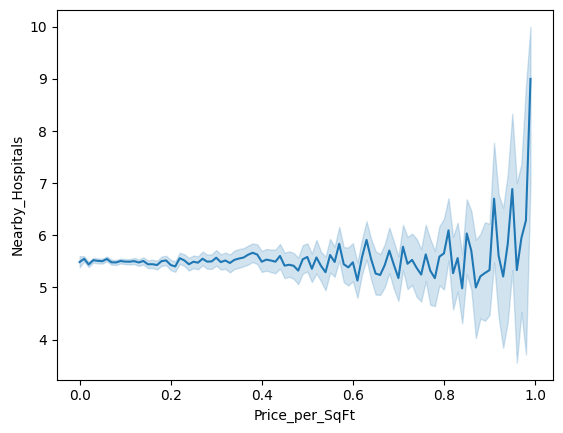

In [ ]:
sns.lineplot(x = df2['Price_per_SqFt'], y = df2['Nearby_Hospitals'])

plt.show()

### 14) How does price vary by furnished status?

In [ ]:
df2.groupby('Furnished_Status')['Price'].mean()

Furnished_Status
Furnished         2.544455e+07
Semi-furnished    2.543348e+07
Unfurnished       2.549798e+07
Name: Price, dtype: float64

[]

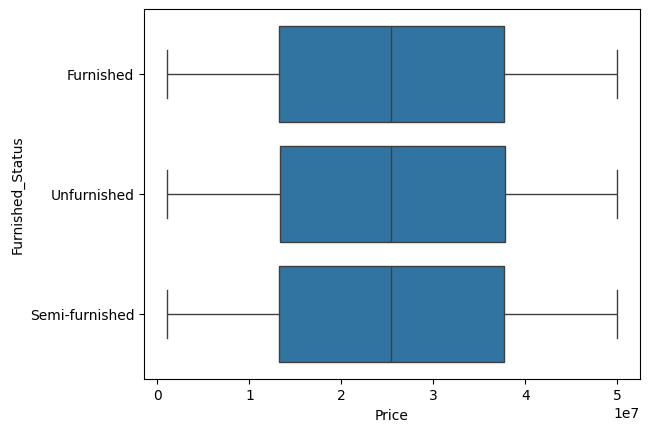

In [ ]:
sns.boxplot(data = df2, x = 'Price', y='Furnished_Status')

plt.plot()

### 15) How does price per sq ft vary by property facing direction?


In [ ]:
df2.groupby(['Facing'])['Price_per_SqFt'].mean()

Facing
East     13023.204130
North    13024.365184
South    13043.611419
West     13139.525439
Name: Price_per_SqFt, dtype: float64

[]

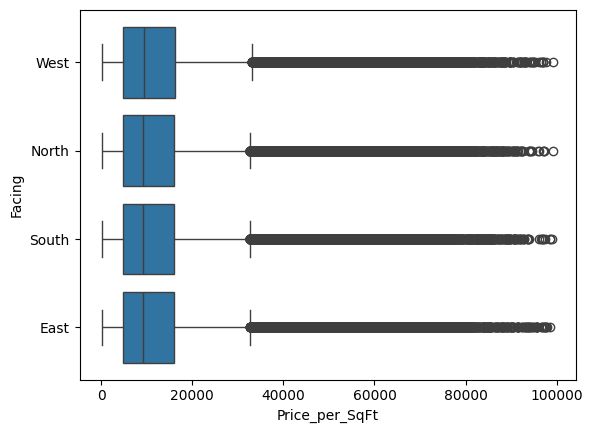

In [ ]:
sns.boxplot(data = df2, x = 'Price_per_SqFt', y='Facing')

plt.plot()

## Investment / Amenities / Ownership Analysis

### 16) How many properties belong to each owner type>

In [ ]:
df2.groupby(['Property_Type', 'Owner_Type'])['Owner_Type'].count()

Property_Type      Owner_Type
Apartment          Broker        27786
                   Builder       27529
                   Owner         27641
Independent House  Broker        27733
                   Builder       27792
                   Owner         27775
Villa              Broker        27960
                   Builder       27932
                   Owner         27852
Name: Owner_Type, dtype: int64

### 17) How many properties are available under each availability status?

In [ ]:
df2.groupby(['Availability_Status'])['Availability_Status'].count()

Availability_Status
Ready_to_Move         124965
Under_Construction    125035
Name: Availability_Status, dtype: int64

In [ ]:
df2.groupby(['Property_Type', 'Availability_Status'])['Availability_Status'].count()

Property_Type      Availability_Status
Apartment          Ready_to_Move          41666
                   Under_Construction     41290
Independent House  Ready_to_Move          41522
                   Under_Construction     41778
Villa              Ready_to_Move          41777
                   Under_Construction     41967
Name: Availability_Status, dtype: int64

### 18) Does parking space affect property price?

In [ ]:
df2.groupby('Parking_Space')['Price'].mean()

Parking_Space
No     2.544294e+07
Yes    2.547455e+07
Name: Price, dtype: float64

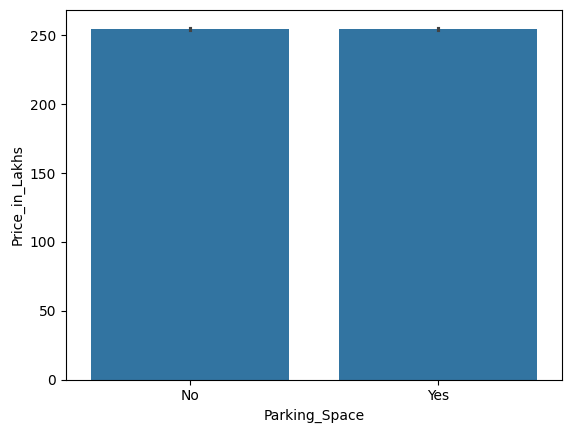

In [ ]:
sns.barplot(data = df1, x = 'Parking_Space', y = 'Price_in_Lakhs')

plt.show()

### 19) How do amenities affect price per sq ft?

In [ ]:
df2['Amenities']

ID
1         Playground, Gym, Garden, Pool, Clubhouse
2         Playground, Clubhouse, Pool, Gym, Garden
3                 Clubhouse, Pool, Playground, Gym
4         Playground, Clubhouse, Gym, Pool, Garden
5         Playground, Garden, Gym, Pool, Clubhouse
                            ...                   
249996    Playground, Garden, Gym, Clubhouse, Pool
249997                                  Playground
249998                                  Playground
249999                       Playground, Gym, Pool
250000                                 Gym, Garden
Name: Amenities, Length: 250000, dtype: object

In [ ]:
df2['Amenities'] = df2["Amenities"].apply(lambda x: len(str(x).split(",")))

In [ ]:
df2.groupby('Amenities')['Price_per_SqFt'].mean()

Amenities
1    13014.501637
2    13058.913625
3    13043.548414
4    13070.369068
5    13101.669621
Name: Price_per_SqFt, dtype: float64

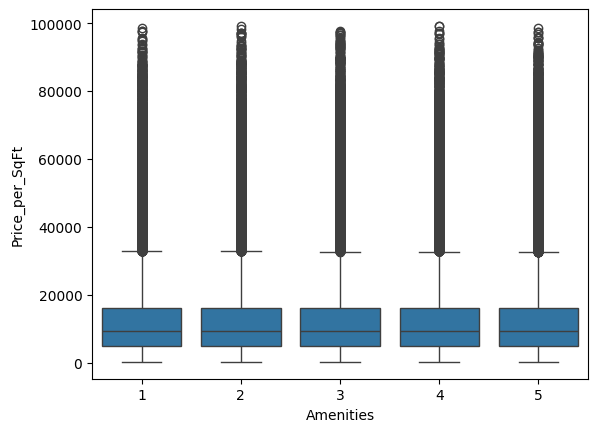

In [ ]:
sns.boxplot(data = df2, x = 'Amenities', y = 'Price_per_SqFt')

plt.show()

## 20) How does public transport accessibility relate to price per sq ft or investment potential?

#### Price_per_SqFt

In [ ]:
df2.groupby('Public_Transport_Accessibility')['Price_per_SqFt'].mean()

Public_Transport_Accessibility
High      13026.743528
Low       13085.040691
Medium    13061.735158
Name: Price_per_SqFt, dtype: float64

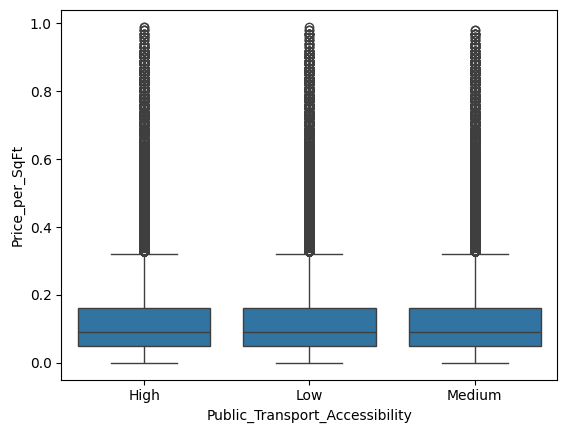

In [ ]:
sns.boxplot(data = df1, x = 'Public_Transport_Accessibility', y = 'Price_per_SqFt')

plt.show()